# Telecom X - Parte 2 - Análise de Evasão de Clientes

Esta etapa dá continuidade ao desafio Telecom X, evoluindo da análise exploratória para a construção de modelos preditivos de churn. O objetivo agora é preparar os dados, treinar e avaliar modelos de Machine Learning para antecipar cancelamentos e apoiar estratégias de retenção mais assertivas.


# 🛠️ Preparação dos Dados

In [106]:

# Importação das bibliotecas principais
import pandas as pd
import numpy as sn
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import numpy as np

In [107]:

# Extração do Arquivo Tratado
url_dados = 'https://raw.githubusercontent.com/gracielejuarez/Challenge-Data-Science-Telecom-X-parte-2/refs/heads/main/dados_tratados_TelecomX.csv'

# Carregando os dados
dados = pd.read_csv(url_dados)
dados.head()

,id,Churn,genero,idoso,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.6,593.30,2.186667
1,0003-MKNFE,não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.9,542.40,1.996667
2,0004-TLHLJ,sim,Masculino,0,Não,Não,4,Sim,Não,Fibra óptica,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.9,280.85,2.463333
3,0011-IGKFF,sim,Masculino,1,Sim,Não,13,Sim,Não,Fibra óptica,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.0,1237.85,3.266667
4,0013-EXCHZ,sim,Feminino,1,Sim,Não,3,Sim,Não,Fibra óptica,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.9,267.40,2.796667


In [108]:
dados.describe()

,idoso,tempo_contrato,valor_mensal,total_cobrado,contas_diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,2.159940
std,0.368844,24.545260,30.085974,2266.771362,1.002866
min,0.000000,1.000000,18.250000,18.800000,0.608333
25%,0.000000,9.000000,35.587500,401.450000,1.186250
50%,0.000000,29.000000,70.350000,1397.475000,2.345000
75%,0.000000,55.000000,89.862500,3794.737500,2.995417
max,1.000000,72.000000,118.750000,8684.800000,3.958333


In [109]:
dados.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    7032 non-null   object 
 1   Churn                 7032 non-null   object 
 2   genero                7032 non-null   object 
 3   idoso                 7032 non-null   int64  
 4   possui_parceiro       7032 non-null   object 
 5   possui_dependentes    7032 non-null   object 
 6   tempo_contrato        7032 non-null   int64  
 7   servico_telefone      7032 non-null   object 
 8   multiplas_linhas      7032 non-null   object 
 9   tipo_internet         7032 non-null   object 
 10  seguranca_online      7032 non-null   object 
 11  backup_online         7032 non-null   object 
 12  protecao_dispositivo  7032 non-null   object 
 13  suporte_tecnico       7032 non-null   object 
 14  streaming_tv          7032 non-null   object 
 15  streaming_filmes     

In [110]:
dados.columns

Index(['id', 'Churn', 'genero', 'idoso', 'possui_parceiro',
       'possui_dependentes', 'tempo_contrato', 'servico_telefone',
       'multiplas_linhas', 'tipo_internet', 'seguranca_online',
       'backup_online', 'protecao_dispositivo', 'suporte_tecnico',
       'streaming_tv', 'streaming_filmes', 'tipo_contrato', 'fatura_digital',
       'metodo_pagamento', 'valor_mensal', 'total_cobrado', 'contas_diarias'],
      dtype='object')

In [111]:
# Remoção de Colunas Irrelevantes
dados.drop(columns=['id'], inplace=True)
dados.head()

,Churn,genero,idoso,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,Não,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.6,593.30,2.186667
1,não,Masculino,0,Não,Não,9,Sim,Sim,DSL,Não,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.9,542.40,1.996667
2,sim,Masculino,0,Não,Não,4,Sim,Não,Fibra óptica,Não,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.9,280.85,2.463333
3,sim,Masculino,1,Sim,Não,13,Sim,Não,Fibra óptica,Não,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.0,1237.85,3.266667
4,sim,Feminino,1,Sim,Não,3,Sim,Não,Fibra óptica,Não,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.9,267.40,2.796667


In [112]:
for col in dados.columns:
  print(f'{col}: {dados[col].nunique()}')
  if dados[col].nunique() < 100:
    print(dados[col].unique())
  else:
    print('Muitos registros únicos para imprimir.')
  print('-' * 50)

Churn: 2
['não' 'sim']
--------------------------------------------------
genero: 2
['Feminino' 'Masculino']
--------------------------------------------------
idoso: 2
[0 1]
--------------------------------------------------
possui_parceiro: 2
['Sim' 'Não']
--------------------------------------------------
possui_dependentes: 2
['Sim' 'Não']
--------------------------------------------------
tempo_contrato: 72
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42]
--------------------------------------------------
servico_telefone: 2
['Sim' 'Não']
--------------------------------------------------
multiplas_linhas: 3
['Não' 'Sim' 'Sem serviço de telefone']
--------------------------------------------------
tipo_internet: 3
['DSL' 'Fibra óptica' 'Não']
--------------------------------------------------
seguranca_online: 3


In [113]:
colunas_correcao = [
    'seguranca_online', 'backup_online', 'protecao_dispositivo',
    'suporte_tecnico', 'streaming_tv', 'streaming_filmes'
]

for col in colunas_correcao :
    dados[col] = dados[col].replace( 'Sem serviço de internet', 'Não')


In [114]:
for col in dados.columns:
  print(f'{col}: {dados[col].nunique()}')
  if dados[col].nunique() < 100:
    print(dados[col].unique())
  else:
    print('Muitos registros únicos para imprimir.')
  print('-' * 50)

Churn: 2
['não' 'sim']
--------------------------------------------------
genero: 2
['Feminino' 'Masculino']
--------------------------------------------------
idoso: 2
[0 1]
--------------------------------------------------
possui_parceiro: 2
['Sim' 'Não']
--------------------------------------------------
possui_dependentes: 2
['Sim' 'Não']
--------------------------------------------------
tempo_contrato: 72
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42]
--------------------------------------------------
servico_telefone: 2
['Sim' 'Não']
--------------------------------------------------
multiplas_linhas: 3
['Não' 'Sim' 'Sem serviço de telefone']
--------------------------------------------------
tipo_internet: 3
['DSL' 'Fibra óptica' 'Não']
--------------------------------------------------
seguranca_online: 2


In [115]:
# Calculando a proporção de Churn
churn_counts = dados['Churn'].value_counts()
churn_percentage = dados['Churn'].value_counts(normalize=True) * 100

# Exibindo os resultados
print("Contagem de Churn:")
print(churn_counts)
print("\nProporção de Churn (%):")
print(churn_percentage)

Contagem de Churn:
Churn
não    5163
sim    1869
Name: count, dtype: int64

Proporção de Churn (%):
Churn
não    73.421502
sim    26.578498
Name: proportion, dtype: float64


In [116]:
px.histogram(dados, x = 'Churn', text_auto = True)

In [117]:
#Ecoding
x = dados.drop('Churn', axis = 1)
y = dados['Churn']

x.head()

,genero,idoso,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,seguranca_online,backup_online,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,Feminino,0,Sim,Sim,9,Sim,Não,DSL,Não,Sim,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.6,593.30,2.186667
1,Masculino,0,Não,Não,9,Sim,Sim,DSL,Não,Não,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.9,542.40,1.996667
2,Masculino,0,Não,Não,4,Sim,Não,Fibra óptica,Não,Não,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.9,280.85,2.463333
3,Masculino,1,Sim,Não,13,Sim,Não,Fibra óptica,Não,Sim,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.0,1237.85,3.266667
4,Feminino,1,Sim,Não,3,Sim,Não,Fibra óptica,Não,Não,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.9,267.40,2.796667


In [118]:
y.head()

,Churn
0,não
1,não
2,sim
3,sim
4,sim


In [119]:
#Transformando as variáveis explicativas
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [120]:
colunas = x.columns
colunas

Index(['genero', 'idoso', 'possui_parceiro', 'possui_dependentes',
       'tempo_contrato', 'servico_telefone', 'multiplas_linhas',
       'tipo_internet', 'seguranca_online', 'backup_online',
       'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv',
       'streaming_filmes', 'tipo_contrato', 'fatura_digital',
       'metodo_pagamento', 'valor_mensal', 'total_cobrado', 'contas_diarias'],
      dtype='object')

In [121]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['genero', 'possui_parceiro', 'possui_dependentes',
       'servico_telefone', 'multiplas_linhas',
       'tipo_internet', 'seguranca_online', 'backup_online',
       'protecao_dispositivo', 'suporte_tecnico', 'streaming_tv',
       'streaming_filmes', 'tipo_contrato', 'fatura_digital',
       'metodo_pagamento']
),
    remainder = 'passthrough',
    sparse_threshold=0)

In [122]:
x = one_hot.fit_transform(x)

In [123]:
one_hot.get_feature_names_out(colunas)

array(['onehotencoder__genero_Masculino',
       'onehotencoder__possui_parceiro_Sim',
       'onehotencoder__possui_dependentes_Sim',
       'onehotencoder__servico_telefone_Sim',
       'onehotencoder__multiplas_linhas_Não',
       'onehotencoder__multiplas_linhas_Sem serviço de telefone',
       'onehotencoder__multiplas_linhas_Sim',
       'onehotencoder__tipo_internet_DSL',
       'onehotencoder__tipo_internet_Fibra óptica',
       'onehotencoder__tipo_internet_Não',
       'onehotencoder__seguranca_online_Sim',
       'onehotencoder__backup_online_Sim',
       'onehotencoder__protecao_dispositivo_Sim',
       'onehotencoder__suporte_tecnico_Sim',
       'onehotencoder__streaming_tv_Sim',
       'onehotencoder__streaming_filmes_Sim',
       'onehotencoder__tipo_contrato_Anual',
       'onehotencoder__tipo_contrato_Bienal',
       'onehotencoder__tipo_contrato_Mensal',
       'onehotencoder__fatura_digital_Sim',
       'onehotencoder__metodo_pagamento_Cartão de crédito (automático)

In [124]:
pd.DataFrame(x, columns = one_hot.get_feature_names_out(colunas))

,onehotencoder__genero_Masculino,onehotencoder__possui_parceiro_Sim,onehotencoder__possui_dependentes_Sim,onehotencoder__servico_telefone_Sim,onehotencoder__multiplas_linhas_Não,onehotencoder__multiplas_linhas_Sem serviço de telefone,onehotencoder__multiplas_linhas_Sim,onehotencoder__tipo_internet_DSL,onehotencoder__tipo_internet_Fibra óptica,onehotencoder__tipo_internet_Não,...,onehotencoder__fatura_digital_Sim,onehotencoder__metodo_pagamento_Cartão de crédito (automático),onehotencoder__metodo_pagamento_Cheque eletrônico,onehotencoder__metodo_pagamento_Cheque enviado,onehotencoder__metodo_pagamento_Transferência bancária (automática),remainder__idoso,remainder__tempo_contrato,remainder__valor_mensal,remainder__total_cobrado,remainder__contas_diarias
0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,9.0,65.60,593.30,2.186667
1,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,9.0,59.90,542.40,1.996667
2,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,4.0,73.90,280.85,2.463333
3,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,13.0,98.00,1237.85,3.266667
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,3.0,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,13.0,55.15,742.90,1.838333
7028,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,22.0,85.10,1873.70,2.836667
7029,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,2.0,50.30,92.75,1.676667
7030,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,67.0,67.85,4627.65,2.261667


# Correlação e Seleção de Variáveis

**Análise de Correlação**

0 indica ausência da característica da variável e 1 representa a presença da característica.

In [125]:
from sklearn.preprocessing import LabelEncoder

In [126]:
label_ecoder = LabelEncoder()

In [127]:
y = label_ecoder.fit_transform(y)

In [128]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [129]:
# Identificar colunas numéricas
dados_numericos = dados.select_dtypes(include=[np.number])
print("Colunas numéricas encontradas:", dados_numericos.columns.tolist())

Colunas numéricas encontradas: ['idoso', 'tempo_contrato', 'valor_mensal', 'total_cobrado', 'contas_diarias']


In [130]:
# Correlação
correlacao = dados_numericos.corr()
correlacao

,idoso,tempo_contrato,valor_mensal,total_cobrado,contas_diarias
idoso,1.000000,0.015683,0.219874,0.102411,0.219874
tempo_contrato,0.015683,1.000000,0.246862,0.825880,0.246862
valor_mensal,0.219874,0.246862,1.000000,0.651065,1.000000
total_cobrado,0.102411,0.825880,0.651065,1.000000,0.651065
contas_diarias,0.219874,0.246862,1.000000,0.651065,1.000000


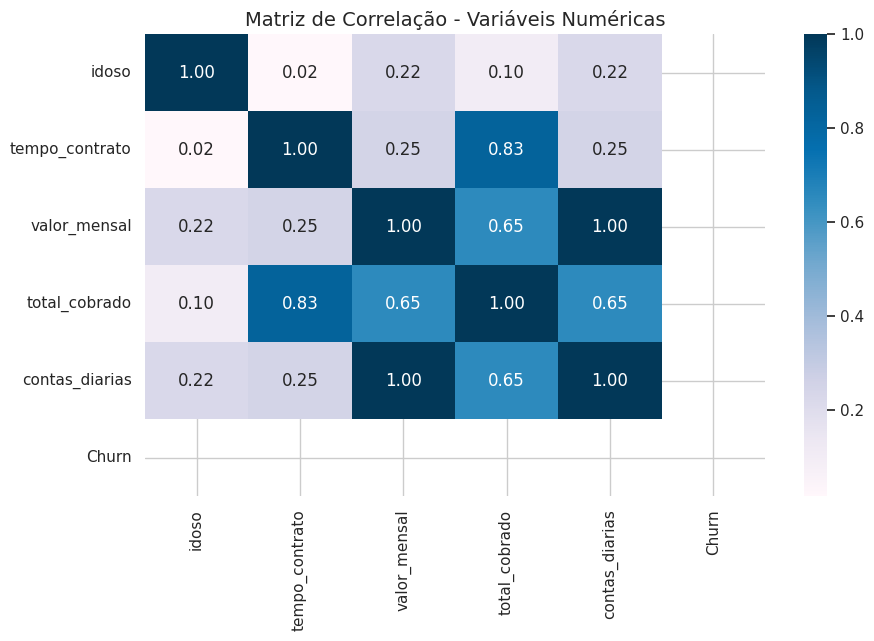

In [131]:
# Selecionar apenas variáveis numéricas
df_numeric = dados.select_dtypes(include=["int64", "float64"])

# Converter Churn para numérico
df_numeric["Churn"] = dados["Churn"].map({"Yes": 1, "No": 0})


# Calcular matriz de correlação
corr_matrix = df_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="PuBu",
            fmt=".2f")

plt.title("Matriz de Correlação - Variáveis Numéricas", fontsize=14)
plt.show()



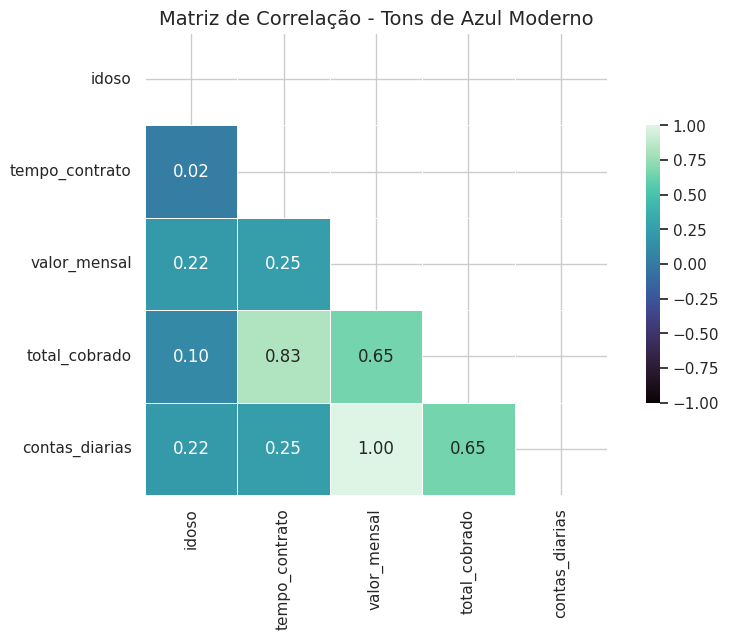

In [132]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Criar máscara para esconder a parte superior
mascara = np.zeros_like(correlacao, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

# Configurar figura
f, ax = plt.subplots(figsize=(10, 6))

# Paleta azul moderna (gradiente elegante)
cmap = sns.color_palette("mako", as_cmap=True)

# Heatmap
sns.heatmap(
    correlacao,
    mask=mascara,
    cmap=cmap,
    vmax=1,
    vmin=-1,
    center=0,
    square=True,
    linewidths=.5,
    annot=True,
    fmt=".2f",
    cbar_kws={"shrink": .6}
)

plt.title("Matriz de Correlação - Tons de Azul Moderno", fontsize=14)
plt.show()

**Análises Direcionadas**

É importante analisar a distribuição do tempo de contrato e do valor total gasto para identificar diferenças entre clientes que permanecem e os que cancelam o serviço.

/tmp/ipykernel_357/1070404073.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_357/1070404073.py:11: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




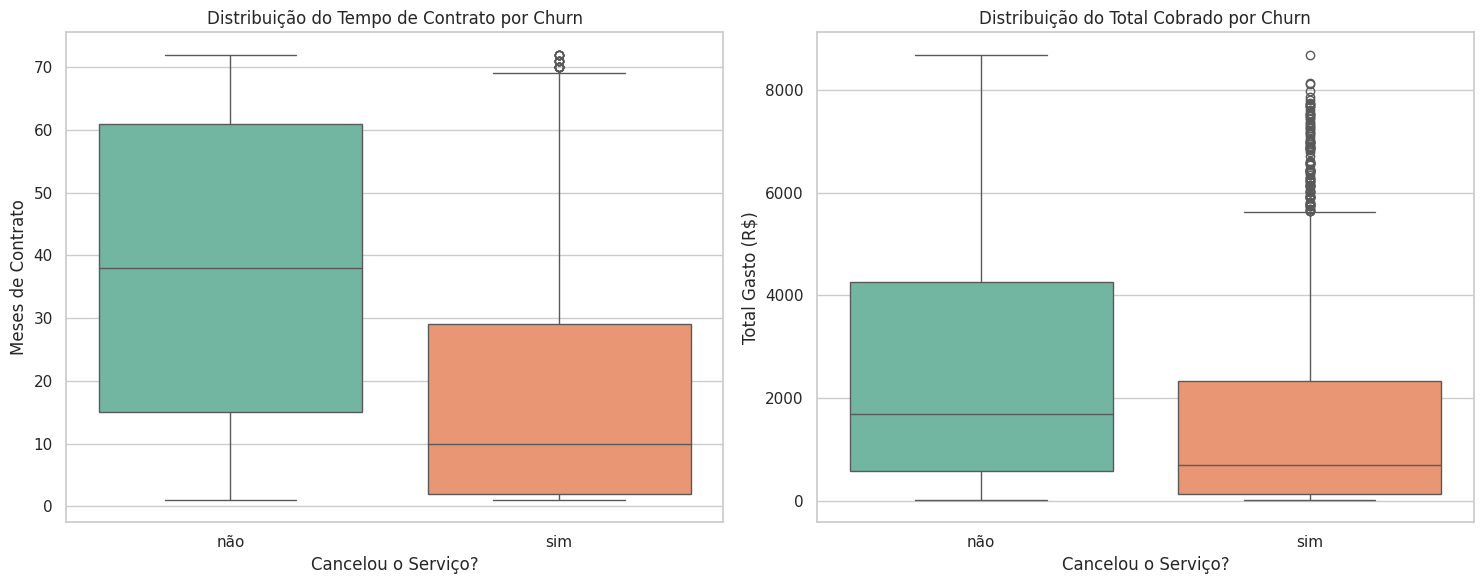

In [133]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Tempo de contrato × Evasão
sns.boxplot(x='Churn', y='tempo_contrato', data=dados, ax=axes[0], palette='Set2')
axes[0].set_title('Distribuição do Tempo de Contrato por Churn')
axes[0].set_xlabel('Cancelou o Serviço?')
axes[0].set_ylabel('Meses de Contrato')

# Gráfico 2: Total gasto × Evasão
sns.boxplot(x='Churn', y='total_cobrado', data=dados, ax=axes[1], palette='Set2')
axes[1].set_title('Distribuição do Total Cobrado por Churn')
axes[1].set_xlabel('Cancelou o Serviço?')
axes[1].set_ylabel('Total Gasto (R$)')

plt.tight_layout()
plt.show()

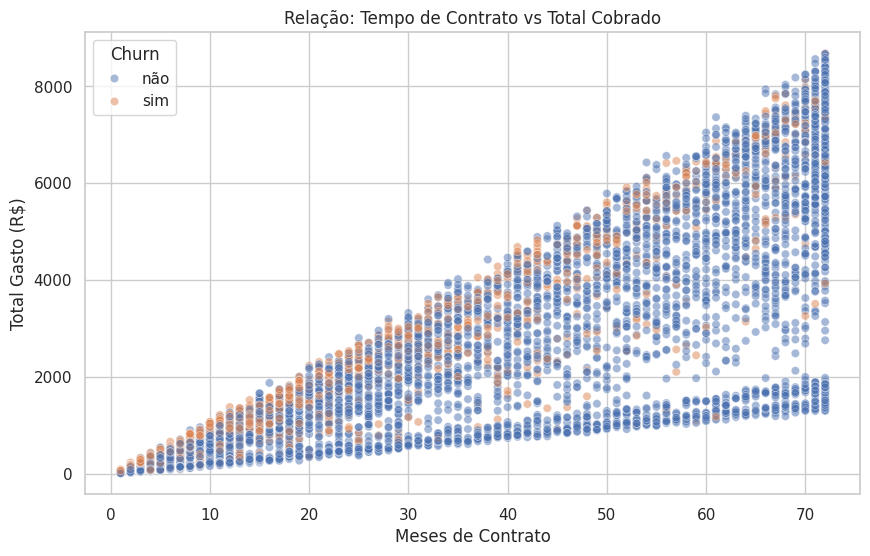

In [134]:
# Gráfico 1: Tempo de contrato × Total Cobrado
plt.figure(figsize=(10, 6))
sns.scatterplot(x='tempo_contrato', y='total_cobrado', hue='Churn', data=dados, alpha=0.5)
plt.title('Relação: Tempo de Contrato vs Total Cobrado')
plt.xlabel('Meses de Contrato')
plt.ylabel('Total Gasto (R$)')
plt.show()

**Avaliação dos Modelos**

Aqui separamos os dados em treino e teste para ajustar o modelo.

In [135]:
from sklearn.model_selection import train_test_split

In [136]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, stratify = y,  random_state = 5)


In [137]:
from sklearn.dummy import DummyClassifier

In [138]:
dummy = DummyClassifier()
dummy.fit(x_treino, y_treino)

dummy.score(x_teste, y_teste)

0.7343572241183163

**Árvore de Decisão**

In [139]:
from sklearn.tree import DecisionTreeClassifier

In [140]:
arvore = DecisionTreeClassifier(max_depth = 3, random_state =5)
arvore.fit(x_treino, y_treino)

DecisionTreeClassifier(max_depth=3, random_state=5)

In [141]:
arvore.predict(x_teste)

array([0, 0, 0, ..., 0, 0, 0])

In [142]:
arvore.score(x_teste, y_teste)

0.7878270762229806

In [143]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

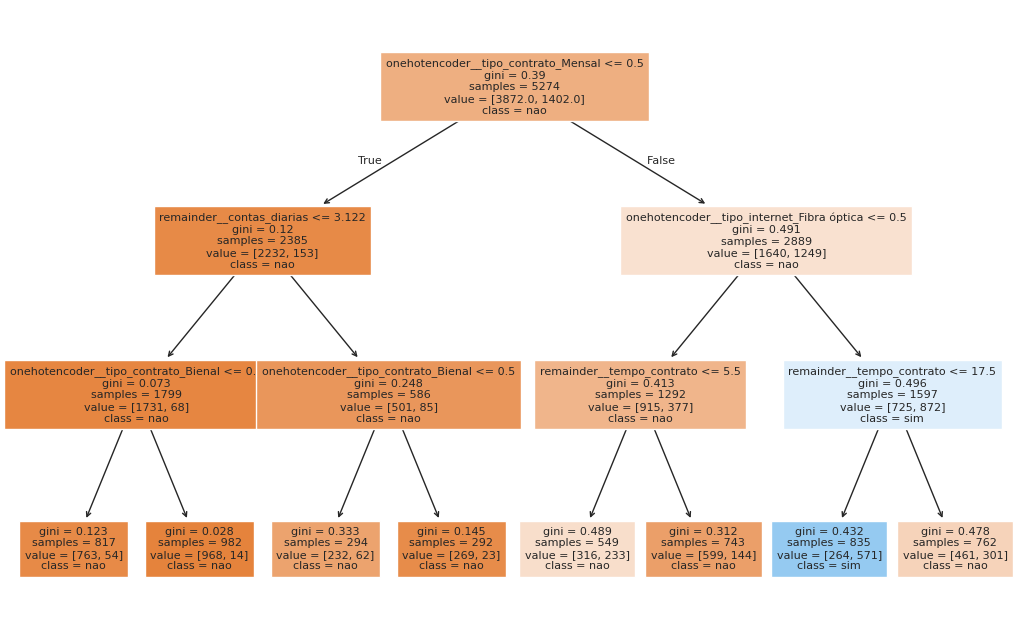

In [94]:
plt.figure(figsize = (13, 8))
nome_colunas = one_hot.get_feature_names_out(colunas)
plot_tree(arvore, filled = True, class_names = ['nao', 'sim'], fontsize = 8, feature_names = nome_colunas);

**Normalizando os dados**

In [95]:
from sklearn.preprocessing import MinMaxScaler

In [96]:
normalizacao = MinMaxScaler()
x_treino_normalizado = normalizacao.fit_transform(x_treino)

In [97]:
pd.DataFrame(x_treino_normalizado)

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.985915,0.465869,0.538071,0.465869
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.971831,0.715994,0.734726,0.715994
2,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.802817,0.907324,0.706870,0.907324
3,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.830986,0.413054,0.399795,0.413054
4,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.394366,0.757848,0.304041,0.757848
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5269,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.619718,0.627803,0.433536,0.627803
5270,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.577465,0.371201,0.277281,0.371201
5271,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.619718,0.015944,0.100110,0.015944
5272,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.394366,0.475336,0.218476,0.475336


**KNN**

In [98]:
from sklearn.neighbors import KNeighborsClassifier

In [99]:
knn = KNeighborsClassifier()

In [100]:
knn.fit(x_treino_normalizado, y_treino)

KNeighborsClassifier()

In [101]:
x_teste_normalizado = normalizacao.transform(x_teste)

In [102]:
knn.score(x_teste_normalizado, y_teste)

0.7536973833902162

**Regressão Logística e SVM**

In [103]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import pandas as pd

nomes_colunas = one_hot.get_feature_names_out(colunas)

# 1. Regressão Logística
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(x_treino_normalizado, y_treino)

# 2. SVM (
svm_model = SVC(kernel='linear')
svm_model.fit(x_treino_normalizado, y_treino)

df_coef = pd.DataFrame({
    'Variável': nomes_colunas,
    'Coef_LogReg': log_reg.coef_[0],
    'Coef_SVM': svm_model.coef_[0]
})

print(df_coef.sort_values(by='Coef_LogReg', ascending=False))

                                             Variável  Coef_LogReg  Coef_SVM
27                           remainder__total_cobrado     1.033350 -1.526781
8           onehotencoder__tipo_internet_Fibra óptica     0.655649  1.003782
18                onehotencoder__tipo_contrato_Mensal     0.629717  0.129407
19                  onehotencoder__fatura_digital_Sim     0.337369  0.189565
14                    onehotencoder__streaming_tv_Sim     0.224152  0.234635
21  onehotencoder__metodo_pagamento_Cheque eletrônico     0.223155  0.217524
24                                   remainder__idoso     0.210930  0.209677
15                onehotencoder__streaming_filmes_Sim     0.174636  0.245171
28                          remainder__contas_diarias     0.074609 -0.236427
26                            remainder__valor_mensal     0.074609 -0.236427
5   onehotencoder__multiplas_linhas_Sem serviço de...     0.042417  0.094570
0                     onehotencoder__genero_Masculino     0.031615 -0.020657

**Random Forest**

In [104]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=5)
rf_model.fit(x_treino, y_treino)


importancia_rf = pd.DataFrame({
    'Variável': nomes_colunas,
    'Importancia': rf_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

importancia_rf.head(10)

,Variável,Importancia
27,remainder__total_cobrado,0.158209
25,remainder__tempo_contrato,0.142115
28,remainder__contas_diarias,0.131416
26,remainder__valor_mensal,0.126537
18,onehotencoder__tipo_contrato_Mensal,0.063308
8,onehotencoder__tipo_internet_Fibra óptica,0.034173
21,onehotencoder__metodo_pagamento_Cheque eletrônico,0.031094
0,onehotencoder__genero_Masculino,0.024352
19,onehotencoder__fatura_digital_Sim,0.022504
17,onehotencoder__tipo_contrato_Bienal,0.021235


/tmp/ipykernel_357/1472431352.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




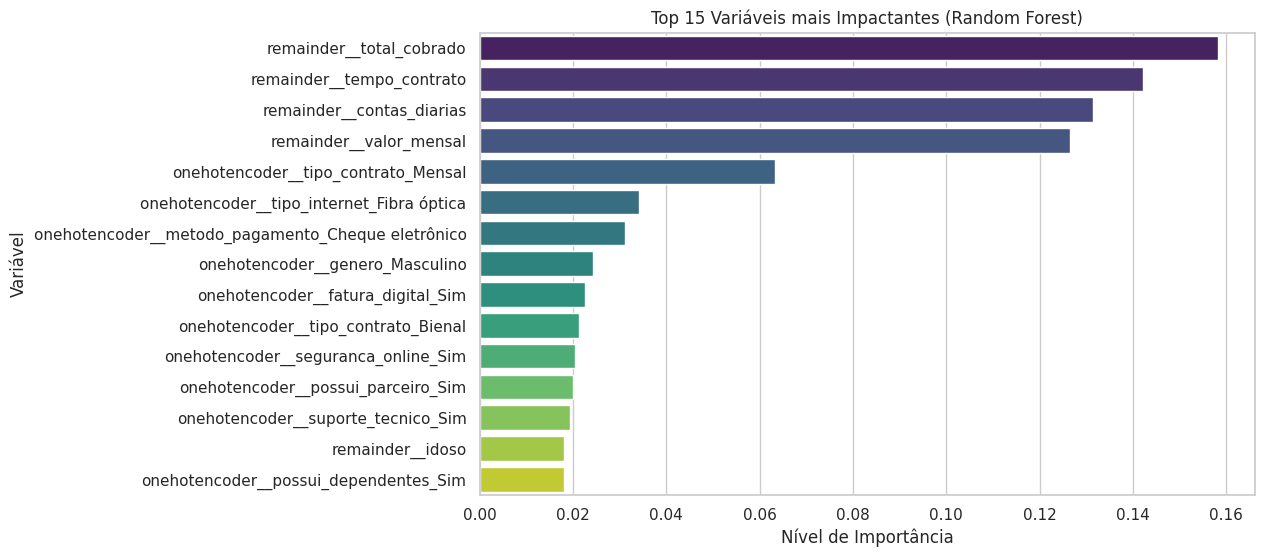

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variável', data=importancia_rf.head(15), palette='viridis')
plt.title('Top 15 Variáveis mais Impactantes (Random Forest)')
plt.xlabel('Nível de Importância')
plt.ylabel('Variável')
plt.show()

# Interpretação e Conclusões



**Análise de Importância das Variáveis**



In [144]:
print(f'Acurácia Dummy: {dummy.score(x_teste, y_teste)}')
print(f'Acurácia Árvore: {arvore.score(x_teste, y_teste)}')
print(f'Acurácia KNN: {knn.score(x_teste_normalizado, y_teste)}')
print(f'Acurácia Regressão Logística: {log_reg.score(x_teste_normalizado, y_teste)}')
print(f'Acurácia SVM: {svm_model.score(x_teste_normalizado, y_teste)}')
print(f'Acurácia Random Forest: {rf_model.score(x_teste, y_teste)}')

Acurácia Dummy: 0.7343572241183163
Acurácia Árvore: 0.7878270762229806
Acurácia KNN: 0.7536973833902162
Acurácia Regressão Logística: 0.8020477815699659
Acurácia SVM: 0.8020477815699659
Acurácia Random Forest: 0.7895335608646189


Os modelos preditivos foram avaliados com base na acurácia, sendo que Regressão Logística e SVM apresentaram os melhores resultados, ambos com 80,20% de acurácia.

Esses resultados indicam que os modelos conseguem identificar padrões relevantes relacionados à evasão de clientes, demonstrando potencial para apoiar estratégias de identificação e retenção de clientes com maior risco de cancelamento.

# **Conclusão**


A análise permitiu identificar fatores relevantes associados à evasão de clientes. Entre as variáveis mais influentes destacam-se o tempo de permanência (tenure), o tipo de contrato e o valor total gasto, indicando que clientes com menor tempo de relacionamento e contratos mensais apresentam maior probabilidade de cancelamento. Também foram observados indícios de maior risco de churn entre clientes de fibra óptica e determinados métodos de pagamento, enquanto contratos de longo prazo, tempo de permanência elevado e serviços adicionais, como suporte técnico e segurança online, estão associados a maior retenção.

Os modelos de Machine Learning contribuíram para identificar esses padrões e reforçam o potencial da análise preditiva como apoio à tomada de decisão.

Com base nesses insights, algumas ações estratégicas podem ser consideradas:

Focar ações de retenção nos primeiros meses de contrato, período com maior risco de evasão;

Incentivar contratos de longo prazo, com benefícios progressivos;

Monitorar clientes com maior valor mensal e risco de churn;

Estimular métodos de pagamento automáticos;

Integrar modelos preditivos às estratégias de relacionamento, permitindo identificar e agir preventivamente sobre clientes com maior probabilidade de cancelamento.